# Lecture 8 · Convolution, shapes & parameter counts from scratch

**Goal** · implement 2D cross-correlation in NumPy, reproduce the lecture's worked numeric example, run an edge kernel on a toy image, and count output sizes & parameters by hand.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

## 1 · 2D cross-correlation (what libraries call “convolution”)

$$Y[i,j]=\sum_{u,v} K[u,v]\, X[i+u,\,j+v].$$

In [2]:
def conv2d(X, K):
    kh, kw = K.shape
    H, W = X.shape
    out = np.zeros((H - kh + 1, W - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(X[i:i+kh, j:j+kw] * K)
    return out

## 2 · Worked numeric example

A patch and a vertical-edge kernel from the slides give a single output of $0$:

In [3]:
patch = np.array([[1, 2, 0],
                  [0, 1, 3],
                  [2, 1, 0]], float)
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]], float)
print('output =', conv2d(patch, kernel).ravel()[0], ' (lecture: (1+0+2)-(0+3+0)=0)')

output = 0.0  (lecture: (1+0+2)-(0+3+0)=0)


## 3 · A kernel is a feature detector

Apply the vertical-edge kernel to a toy image with a bright square: it lights up the vertical edges.

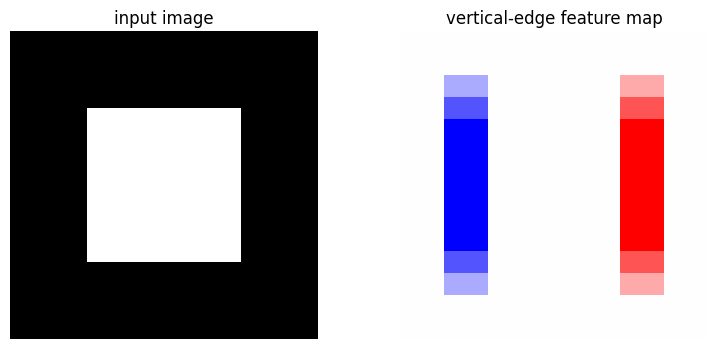

In [4]:
img = np.zeros((16, 16))
img[4:12, 4:12] = 1.0
fmap = conv2d(img, kernel)
fig, ax = plt.subplots(1, 2, figsize=(8, 3.6))
ax[0].imshow(img, cmap='gray'); ax[0].set_title('input image')
ax[1].imshow(fmap, cmap='bwr'); ax[1].set_title('vertical-edge feature map')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 4 · Output-size formula

$$H_{out}=\left\lfloor\frac{H+2p-k}{s}\right\rfloor+1.$$

In [5]:
def out_size(H, k, p, s):
    return (H + 2 * p - k) // s + 1

print('H=32, k=5, p=2, s=1 ->', out_size(32, 5, 2, 1), '(same size)')
print('H=32, k=3, p=1, s=2 ->', out_size(32, 3, 1, 2), '(halved)')

H=32, k=5, p=2, s=1 -> 32 (same size)
H=32, k=3, p=1, s=2 -> 16 (halved)


## 5 · Parameter counts

A conv layer has $k_h k_w C_{in} C_{out} + C_{out}$ parameters — weight sharing makes it far smaller than a dense layer.

In [6]:
def conv_params(k, c_in, c_out):
    return k * k * c_in * c_out + c_out

print('3x3, 64 -> 128 :', conv_params(3, 64, 128), '(lecture: 73,856)')

fc = 224 * 224 * 3 * 1000
print(f'dense 224x224x3 -> 1000 : {fc:,} weights  (~1.5e8, why MLPs are hopeless for images)')

3x3, 64 -> 128 : 73856 (lecture: 73,856)
dense 224x224x3 -> 1000 : 150,528,000 weights  (~1.5e8, why MLPs are hopeless for images)


In [7]:
# cross-check our from-scratch conv against PyTorch, if available
try:
    import torch, torch.nn.functional as F
    Xt = torch.tensor(img)[None, None]
    Kt = torch.tensor(kernel)[None, None]
    ref = F.conv2d(Xt, Kt)[0, 0].numpy()
    print('max abs diff vs torch.conv2d:', float(np.max(np.abs(ref - fmap))))
except Exception as e:
    print('torch not available, skipping cross-check:', e)

max abs diff vs torch.conv2d: 0.0


## Takeaway

- Convolution = a small shared kernel slid over the image; it detects local patterns (edges here).
- Output size follows $\lfloor(H+2p-k)/s\rfloor+1$; padding keeps size, stride shrinks it.
- Weight sharing makes a conv layer orders of magnitude smaller than the equivalent dense layer.